In [7]:
!pip install sentence-transformers

In [8]:
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

In [9]:
sentences = [
    "The batsman hits a straight six",
    "The wicket keeper stumped the batsman brilliantly",
    "He is a talented spin bowler",
    "The water is boiling at a high temperature",
    "The soup simmered slowly on the stove",
    "She is a famous chef in the town",
    "My firewall is going down",
    "His mobile phone was hacked and he lost five thousand rupees",
    "He reported the incident to the cybersecurity cell",
    "The bowler took three wickets in one over"
]

print(f"Total sentences: {len(sentences)}")

Total sentences: 10


In [10]:

model = SentenceTransformer('all-MiniLM-L6-v2')


embeddings = model.encode(sentences)

print(f"Embedding shape: {embeddings.shape}")



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding shape: (10, 384)


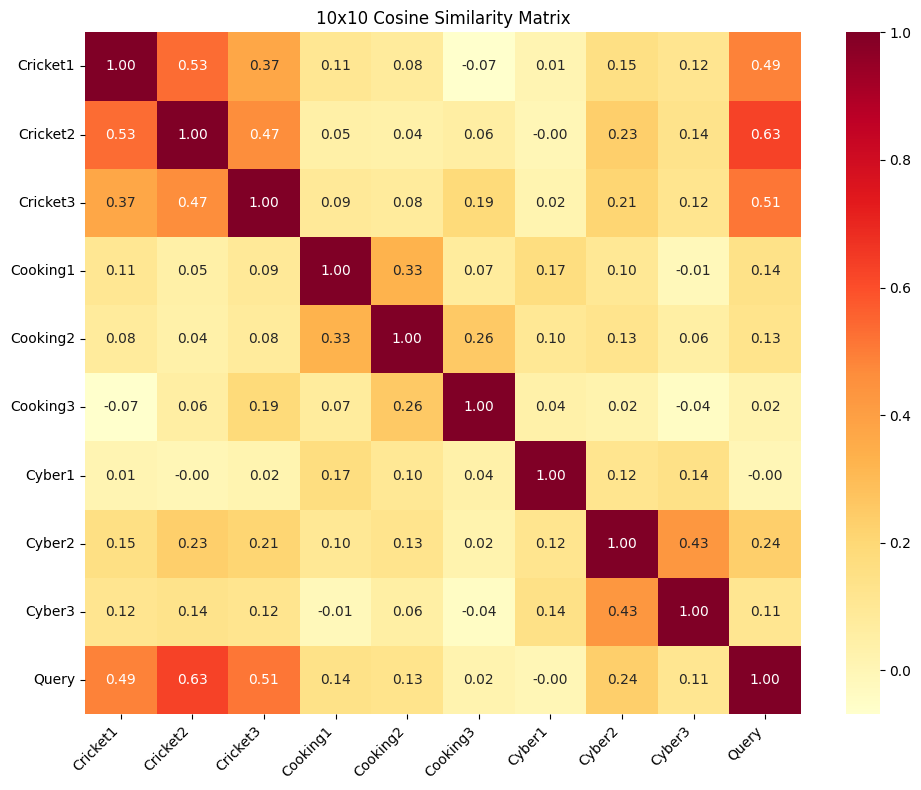

In [11]:
# Compute cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Short labels for display
labels = [
    "Cricket1", "Cricket2", "Cricket3",
    "Cooking1", "Cooking2", "Cooking3",
    "Cyber1",   "Cyber2",   "Cyber3",
    "Query"
]

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_matrix,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd"
)
plt.title("10x10 Cosine Similarity Matrix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:

query_embedding = embeddings[9]


similarities = cosine_similarity(
    [query_embedding],
    embeddings[:9]
)[0]


top2_indices = np.argsort(similarities)[::-1][:2]

print("Query: 'The bowler took three wickets in one over'")
print("\nTop 2 most similar sentences:")
for rank, idx in enumerate(top2_indices, 1):
    print(f"{rank}. {sentences[idx]}")
    print(f"   Similarity score: {similarities[idx]:.4f}")



Query: 'The bowler took three wickets in one over'

Top 2 most similar sentences:
1. The wicket keeper stumped the batsman brilliantly
   Similarity score: 0.6322
2. He is a talented spin bowler
   Similarity score: 0.5143
